In [1]:
"""
Procurement Project Scheduling and Risk Analysis
(CPM + PRA + Z3 Constraint-Based Optimization)

Problem definition:
This project models the scheduling of a procurement process, including supplier selection,
contract negotiation, production, shipping, customs clearance, transportation, inspection,
and inventory stocking.

Methodology:
1) Critical Path Method (CPM) is used to compute Earliest/Latest Start and Finish times,
   Total Float, Critical Path, and Task Drag under deterministic assumptions.
2) Probabilistic Risk Analysis (PRA) is performed using Monte Carlo simulation to model
   uncertainty in task durations and estimate the distribution of project completion time.
3) Z3 SMT optimization is used to extend the CPM baseline by introducing realistic
   constraints (e.g. non-overlapping tasks due to limited resources) and to compute
   an optimized feasible schedule.

Goal:
To compare deterministic scheduling, probabilistic risk-aware scheduling, and
constraint-based optimization in order to identify critical activities, bottlenecks,
and scheduling flexibility.
"""
from dataclasses import dataclass   #tools for defining data structures
from typing import Dict, Tuple   #tools for defining data structures
import random  #tools for generating random numbers
import statistics  #tools for statistical calculations

import networkx as nx   #tools for drwawing and analyzing graphs
import matplotlib.pyplot as plt #tools for plotting
from z3 import Optimize, Int, Or, sat



In [2]:
#ok
@dataclass(frozen=True)
class Task:
    name: str
    duration: float
    predecessors: Tuple[str, ...] = ()


In [3]:
# ok (12 tasks)
procurement_tasks = {
    "A": Task("A", 3, ()),                 # Supplier selection
    "B": Task("B", 4, ("A",)),              # Contract negotiation
    "C": Task("C", 2, ("A",)),              # Internal demand confirmation 
    "D": Task("D", 1, ("B",)),              # Purchase order issuance 
    "E": Task("E", 10, ("D",)),             # Supplier production / preparation
    "G": Task("G", 8, ("E",)),              # International shipping
    "F": Task("F", 4, ("C",)),              # Import documentation preparation 
    "H": Task("H", 2, ("F",)),              # Customs paperwork review 
    "I": Task("I", 5, ("G", "H")),          # Clearance + inland transport 
    "J": Task("J", 3, ("C",)),              # Warehouse space preparation 
    "K": Task("K", 2, ("I",)),              # Quality inspection 
    "L": Task("L", 1, ("I", "J")),          # Inventory stocking 
}



procurement_activity_desc = {
    "A": "Supplier selection",
    "B": "Contract negotiation",
    "C": "Internal demand confirmation",
    "D": "Purchase order issuance",
    "E": "Supplier production / preparation",
    "F": "Import documentation preparation",
    "G": "International shipping",
    "H": "Customs paperwork review",
    "I": "Clearance + inland transport",
    "J": "Warehouse space preparation",
    "K": "Quality inspection",
    "L": "Inventory stocking",
}


In [4]:
# ok (statistical sigmas for PRA)
procurement_sigmas = {
    "A": 0.5,   # Supplier selection (low uncertainty)
    "B": 1.0,   # Contract negotiation (medium)
    "C": 0.3,   # Internal demand confirmation (low)
    "D": 0.2,   # Purchase order issuance (almost fixed)
    "E": 2.0,   # Supplier production / preparation (high)
    "F": 1.0,   # Import documentation preparation (medium)
    "G": 2.5,   # International shipping (very high)
    "H": 2.0,   # Customs clearance (high)
    "I": 0.5,   # Inland transportation (low-medium)
    "J": 0.7,   # Warehouse space preparation (medium)
    "K": 0.5,   # Quality inspection (low-medium)
    "L": 0.2,   # Inventory stocking (almost fixed)
}

procurement_tasks: Dict[str, Task] = procurement_tasks


In [5]:
#ok
def topological_order(tasks: Dict[str, Task]):
    indeg = {t: 0 for t in tasks}
    succ = {t: [] for t in tasks}

    for t, obj in tasks.items():
        for p in obj.predecessors:
            succ[p].append(t)
            indeg[t] += 1

    q = [t for t in tasks if indeg[t] == 0]
    order = []

    while q:
        n = q.pop(0)
        order.append(n)
        for s in succ[n]:
            indeg[s] -= 1
            if indeg[s] == 0:
                q.append(s)

    return order


In [6]:
#ok
def cpm(tasks: Dict[str, Task]):
    order = topological_order(tasks)
    ES, EF, LS, LF = {}, {}, {}, {}

    # Forward pass==>>ES, EF
    for t in order:
        ES[t] = max([EF[p] for p in tasks[t].predecessors], default=0)
        EF[t] = ES[t] + tasks[t].duration

    project_duration = max(EF.values())

    # Backward pass==>>LS, LF
    for t in reversed(order):
        successors = [s for s in tasks if t in tasks[s].predecessors]
        LF[t] = min([LS[s] for s in successors], default=project_duration)
        LS[t] = LF[t] - tasks[t].duration

    TF = {t: LS[t] - ES[t] for t in tasks}

    return ES, EF, LS, LF, TF, project_duration


In [7]:
def compute_drag(tasks, base_duration):
    drags = {}
    delta = 1  # reduce each task by 1 day

    for t in tasks:
        modified = {}
        for k, v in tasks.items():
            if k == t:
                new_dur = max(1, v.duration - delta)
                modified[k] = Task(k, new_dur, v.predecessors)
            else:
                modified[k] = v

        # cpm returns a tuple: (ES, EF, LS, LF, TF, project_duration)
        new_res = cpm(modified)
        new_duration = new_res[5]          # <-- FIX HERE
        drags[t] = base_duration - new_duration

    return drags



In [8]:
# ok
ES, EF, LS, LF, TF, project_duration = cpm(procurement_tasks)

print("Project Duration:", project_duration, "days\n")
print("Task | ES | EF | LS | LF | Float | Critical")
print("-"*45)

for t in topological_order(procurement_tasks):
    print(f"{t:>4} | {ES[t]:>2} | {EF[t]:>2} | {LS[t]:>2} | {LF[t]:>2} | {TF[t]:>5} | {'YES' if TF[t]==0 else 'NO'}")


Project Duration: 33 days

Task | ES | EF | LS | LF | Float | Critical
---------------------------------------------
   A |  0 |  3 |  0 |  3 |     0 | YES
   B |  3 |  7 |  3 |  7 |     0 | YES
   C |  3 |  5 | 18 | 20 |    15 | NO
   D |  7 |  8 |  7 |  8 |     0 | YES
   F |  5 |  9 | 20 | 24 |    15 | NO
   J |  5 |  8 | 29 | 32 |    24 | NO
   E |  8 | 18 |  8 | 18 |     0 | YES
   H |  9 | 11 | 24 | 26 |    15 | NO
   G | 18 | 26 | 18 | 26 |     0 | YES
   I | 26 | 31 | 26 | 31 |     0 | YES
   K | 31 | 33 | 31 | 33 |     0 | YES
   L | 31 | 32 | 32 | 33 |     1 | NO


In [9]:
# ok
procurement_critical_path = [
    t for t in topological_order(procurement_tasks) if TF[t] == 0
]

print("Procurement Critical Path:")
print(" -> ".join(procurement_critical_path))


Procurement Critical Path:
A -> B -> D -> E -> G -> I -> K


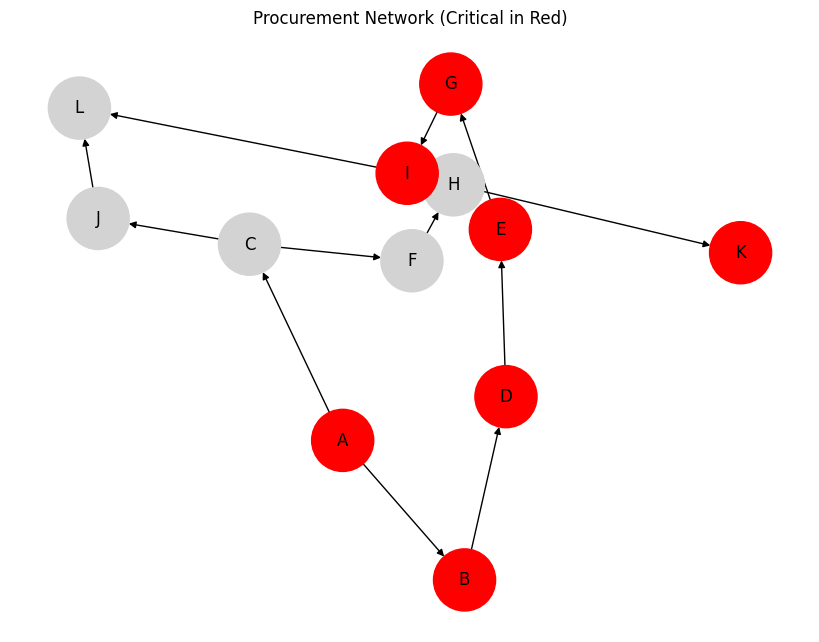

In [10]:
# ok
G = nx.DiGraph()

for t, obj in procurement_tasks.items():
    G.add_node(t)
    for p in obj.predecessors:
        G.add_edge(p, t)

# Color critical tasks in red
colors = ["red" if TF[n] == 0 else "lightgray" for n in G.nodes()]

pos = nx.spring_layout(G, seed=1)

plt.figure(figsize=(8, 6))
nx.draw(
    G,
    pos,
    with_labels=True,
    node_color=colors,
    node_size=2000
)

plt.title("Procurement Network (Critical in Red)")
plt.show()



In [11]:
#ok
def sample_duration(mu, sigma):
    if sigma == 0:
        return int(mu)
    return max(1, int(round(random.gauss(mu, sigma))))


In [12]:
# ok (Monte Carlo PRA)
mc_durations = []
mc_critical_count = {t: 0 for t in procurement_tasks}

N = 1000
random.seed(42)

for _ in range(N):
    sampled_tasks = {
        t: Task(
            t,
            sample_duration(procurement_tasks[t].duration, procurement_sigmas[t]),
            procurement_tasks[t].predecessors
        )
        for t in procurement_tasks
    }

    _, _, _, _, TF_s, dur = cpm(sampled_tasks)
    mc_durations.append(dur)

    for t in sampled_tasks:
        if TF_s[t] == 0:
            mc_critical_count[t] += 1


PRA Mean Duration: 33.05
PRA 95th Percentile: 39

Critical Frequency (%):
A (Supplier selection): 100.0%
B (Contract negotiation): 100.0%
D (Purchase order issuance): 100.0%
E (Supplier production / preparation): 100.0%
G (International shipping): 100.0%
I (Clearance + inland transport): 100.0%
K (Quality inspection): 100.0%
L (Inventory stocking): 17.4%
C (Internal demand confirmation): 0.0%
F (Import documentation preparation): 0.0%
H (Customs paperwork review): 0.0%
J (Warehouse space preparation): 0.0%


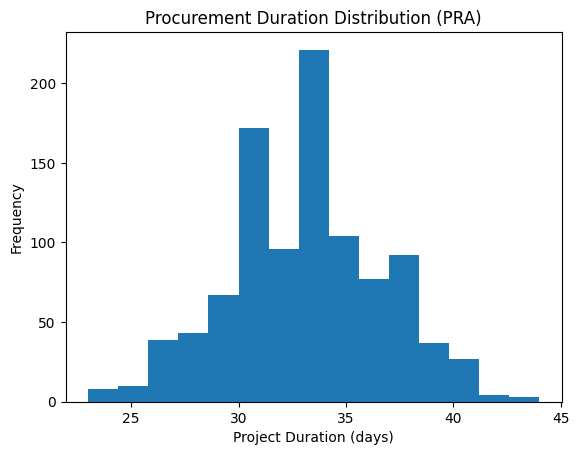

In [13]:
# ok (PRA results)

mc_mean = round(statistics.mean(mc_durations), 2)
mc_p95 = sorted(mc_durations)[int(0.95 * N)]

print("PRA Mean Duration:", mc_mean)
print("PRA 95th Percentile:", mc_p95)

print("\nCritical Frequency (%):")
for t in sorted(mc_critical_count, key=mc_critical_count.get, reverse=True):
    print(f"{t} ({procurement_activity_desc[t]}): {100 * mc_critical_count[t] / N:.1f}%")

plt.hist(mc_durations, bins=15)
plt.xlabel("Project Duration (days)")
plt.ylabel("Frequency")
plt.title("Procurement Duration Distribution (PRA)")
plt.show()



In [14]:
def plot_gantt_with_metrics(
    tasks, ES, EF, LS, LF, TF, drags,
    title="Gantt Chart with Critical Path Highlighted"
):
    # Use the tasks passed to the function (NOT clinic_tasks)
    order = list(reversed(topological_order(tasks)))  # up to down

    plt.figure(figsize=(13, 7))

    for i, t in enumerate(order):
        y = i
        start_es = ES[t]
        dur = tasks[t].duration

        is_critical = (TF[t] == 0)

        # Color by criticality
        color = "tab:red" if is_critical else "tab:blue"

        plt.barh(
            y,
            dur,
            left=start_es,
            height=0.6,
            color=color,
            alpha=0.6,
            edgecolor="black"
        )

        # Left side: ES and LS
        plt.text(start_es - 0.2, y + 0.12, f"ES: {ES[t]}", ha="right", va="center", fontsize=9)
        plt.text(start_es - 0.2, y - 0.12, f"LS: {LS[t]}", ha="right", va="center", fontsize=9)

        # Right side: EF and LF
        plt.text(EF[t] + 0.2, y + 0.12, f"EF: {EF[t]}", ha="left", va="center", fontsize=9)
        plt.text(EF[t] + 0.2, y - 0.12, f"LF: {LF[t]}", ha="left", va="center", fontsize=9)

        # Drag and Float
        plt.text(start_es + dur * 0.65, y + 0.35, f"Drag: {int(round(drags[t]))}",
                 fontsize=9, ha="center")
        plt.text(start_es + dur * 0.65, y + 0.10, f"Float: {int(round(TF[t]))}",
                 fontsize=9, ha="center")

        # Task label
        plt.text(-0.5, y, t, ha="right", va="center", fontsize=11, fontweight="bold")

    plt.yticks(range(len(order)), [""] * len(order))
    plt.xlabel("Time")
    plt.ylabel("Activities")
    plt.title(title)
    plt.grid(True, axis="x", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()



A (Supplier selection)
B (Contract negotiation)
D (Purchase order issuance)
E (Supplier production / preparation)
G (International shipping)
I (Clearance + inland transport)
K (Quality inspection)
L (Inventory stocking)
C (Internal demand confirmation)
F (Import documentation preparation)
H (Customs paperwork review)
J (Warehouse space preparation)


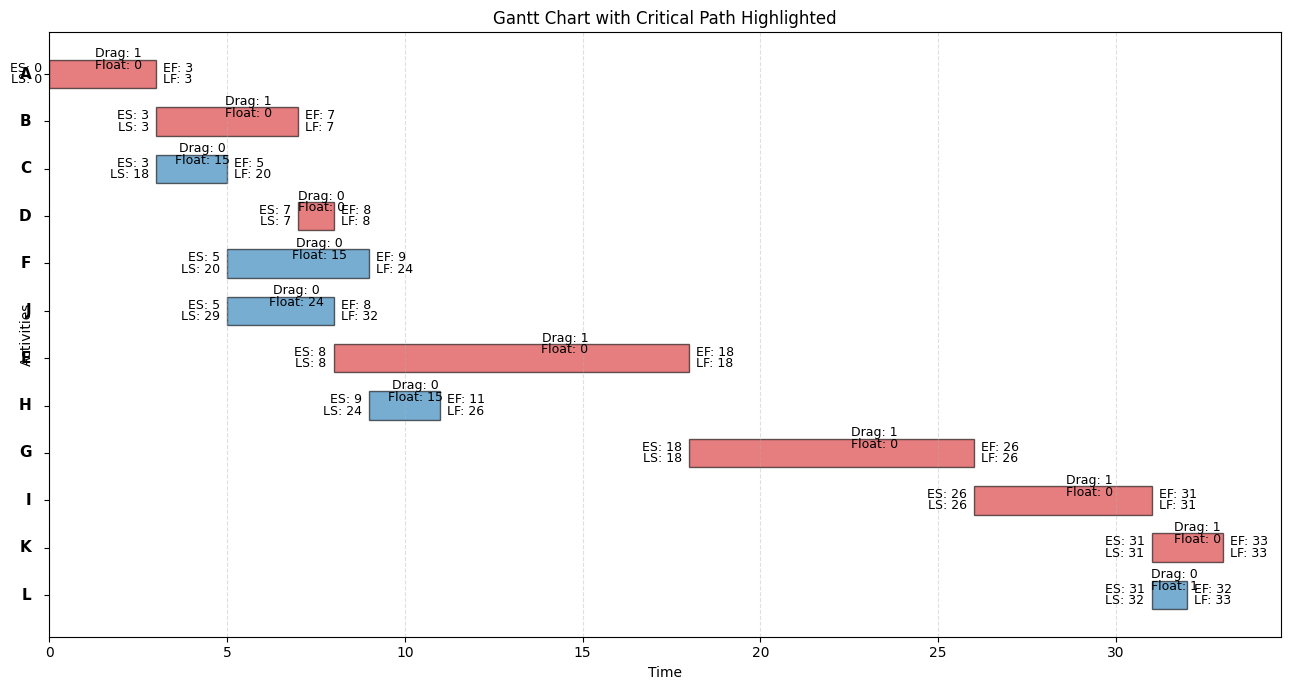

In [15]:

# ok
ES, EF, LS, LF, TF, project_duration = cpm(procurement_tasks)
drags = compute_drag(procurement_tasks, project_duration)


for t in sorted(mc_critical_count, key=mc_critical_count.get, reverse=True):
    print(f"{t} ({procurement_activity_desc[t]})")

plot_gantt_with_metrics(
    procurement_tasks,
    ES, EF, LS, LF, TF, drags,
    title="Gantt Chart with Critical Path Highlighted"
)


In [16]:
def successors_map(tasks):
    succ = {t: [] for t in tasks}
    for t, obj in tasks.items():
        for p in obj.predecessors:
            succ[p].append(t)
    return succ

def has_path(tasks, src, dst):
    # True if there is a precedence chain src -> ... -> dst
    succ = successors_map(tasks)
    stack = [src]
    seen = set([src])
    while stack:
        x = stack.pop()
        if x == dst:
            return True
        for y in succ.get(x, []):
            if y not in seen:
                seen.add(y)
                stack.append(y)
    return False

def independent_pairs(tasks):
    keys = list(tasks.keys())
    pairs = []
    for i in range(len(keys)):
        for j in range(i+1, len(keys)):
            a, b = keys[i], keys[j]
            if (not has_path(tasks, a, b)) and (not has_path(tasks, b, a)):
                pairs.append((a, b))
    return pairs


In [17]:
pairs = independent_pairs(procurement_tasks)
print("Number of independent pairs:", len(pairs))
print("First 20 pairs:", pairs[:20])


Number of independent pairs: 21
First 20 pairs: [('B', 'C'), ('B', 'F'), ('B', 'H'), ('B', 'J'), ('C', 'D'), ('C', 'E'), ('C', 'G'), ('D', 'F'), ('D', 'H'), ('D', 'J'), ('E', 'F'), ('E', 'H'), ('E', 'J'), ('G', 'F'), ('G', 'H'), ('G', 'J'), ('F', 'J'), ('H', 'J'), ('I', 'J'), ('J', 'K')]


In [18]:
test_pair = pairs[0]   # or pick any
z3_starts, z3_makespan = z3_optimize_schedule(procurement_tasks, [test_pair])
print("Test pair:", test_pair, "makespan:", z3_makespan)


NameError: name 'z3_optimize_schedule' is not defined

In [ ]:
# Baseline (no extra resource constraints)
_, base_ms = z3_optimize_schedule(procurement_tasks, [])
print("Baseline makespan:", base_ms)

results = []

for a, b in pairs:
    _, ms = z3_optimize_schedule(procurement_tasks, [(a, b)])
    delta = ms - base_ms
    results.append((a, b, delta, ms))

# sort by biggest impact
results.sort(key=lambda x: x[2], reverse=True)

print("Top impactful resource constraints:")
for r in results[:10]:
    print(f"Pair {r[0], r[1]} → Δ {r[2]} days → makespan {r[3]}")


Baseline makespan: 33
Top impactful resource constraints:
Pair ('K', 'L') → Δ 1 days → makespan 34
Pair ('B', 'C') → Δ 0 days → makespan 33
Pair ('B', 'F') → Δ 0 days → makespan 33
Pair ('B', 'H') → Δ 0 days → makespan 33
Pair ('B', 'J') → Δ 0 days → makespan 33
Pair ('C', 'D') → Δ 0 days → makespan 33
Pair ('C', 'E') → Δ 0 days → makespan 33
Pair ('C', 'G') → Δ 0 days → makespan 33
Pair ('D', 'F') → Δ 0 days → makespan 33
Pair ('D', 'H') → Δ 0 days → makespan 33


In [ ]:

def z3_optimize_schedule(tasks, non_overlap_pairs=None):
    """
    Build and solve a Z3 scheduling model:
    - precedence constraints from tasks[t].predecessors
    - optional non-overlap constraints for limited resources
    - objective: minimize makespan (project duration)
    Returns: start_times dict, makespan int
    """
    if non_overlap_pairs is None:
        non_overlap_pairs = []

    opt = Optimize()

    # Start time variables (integer days)
    S = {t: Int(f"S_{t}") for t in tasks}

    # Start times must be >= 0
    for t in tasks:
        opt.add(S[t] >= 0)

    # Precedence constraints: S[t] >= S[p] + dur(p)
    for t, obj in tasks.items():
        for p in obj.predecessors:
            opt.add(S[t] >= S[p] + int(tasks[p].duration))

    # Makespan: >= finish time of every task
    makespan = Int("makespan")
    opt.add(makespan >= 0)
    for t in tasks:
        opt.add(makespan >= S[t] + int(tasks[t].duration))

    # Non-overlap constraints (resource constraints)
    # Each pair (a,b) means: a and b cannot run at the same time
    for (a, b) in non_overlap_pairs:
        da = int(tasks[a].duration)
        db = int(tasks[b].duration)
        opt.add(Or(S[a] + da <= S[b], S[b] + db <= S[a]))

    # Objective: minimize makespan
    opt.minimize(makespan)

    # Solve
    if opt.check() != sat:
      raise ValueError("No feasible schedule found (UNSAT).")




    model = opt.model()
    start_times = {t: model[S[t]].as_long() for t in tasks}
    ms = model[makespan].as_long()

    return start_times, ms


In [ ]:
# Example: limited resource constraint (end-of-process shared team)
# Quality inspection (K) and inventory stocking (L) cannot overlap (same warehouse/QA resources)
non_overlap_pairs = [("K","L")]

z3_starts, z3_makespan = z3_optimize_schedule(procurement_tasks, non_overlap_pairs)

print("✅ Z3 optimized makespan:", z3_makespan, "days\n")

# Print schedule sorted by start time
print("Task | Start | Finish | Activity")
print("-" * 70)
for t in sorted(z3_starts, key=z3_starts.get):
    st = z3_starts[t]
    dur = int(procurement_tasks[t].duration)
    print(f"{t:>4} | {st:>5} | {st+dur:>6} | {procurement_activity_desc[t]}")


✅ Z3 optimized makespan: 34 days

Task | Start | Finish | Activity
----------------------------------------------------------------------
   A |     0 |      3 | Supplier selection
   B |     3 |      7 | Contract negotiation
   C |     3 |      5 | Internal demand confirmation
   F |     5 |      9 | Import documentation preparation
   J |     5 |      8 | Warehouse space preparation
   D |     7 |      8 | Purchase order issuance
   E |     8 |     18 | Supplier production / preparation
   H |     9 |     11 | Customs paperwork review
   G |    18 |     26 | International shipping
   I |    26 |     31 | Clearance + inland transport
   K |    31 |     33 | Quality inspection
   L |    33 |     34 | Inventory stocking
